<a href="https://colab.research.google.com/github/bhumibhavsar1830-cloud/ShadowFox/blob/main/Car_Selling_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car.csv to car.csv


In [3]:
# ── Step 1: Import Libraries ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [4]:
# ── Step 2: Load Dataset ──────────────────────────────────────────────────────
df = pd.read_csv('car.csv')

print('📊 Dataset Shape:', df.shape)
print(f'   Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
print(f'\n🎯 Target Variable (Selling_Price):')
print(f'   Min: ₹{df["Selling_Price"].min()}L  |  Max: ₹{df["Selling_Price"].max()}L  |  Mean: ₹{df["Selling_Price"].mean():.2f}L')
print(f'\n🔎 Missing Values: {df.isnull().sum().sum()} — Clean dataset!')
df.head(10)

📊 Dataset Shape: (301, 9)
   Rows: 301  |  Columns: 9

🎯 Target Variable (Selling_Price):
   Min: ₹0.1L  |  Max: ₹35.0L  |  Mean: ₹4.66L

🔎 Missing Values: 0 — Clean dataset!


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [5]:
# Statistical Summary
print('📈 Statistical Summary:')
df.describe().round(3)

📈 Statistical Summary:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000,301.000,301.000,301.000,301.000
mean,2013.628,4.661,7.628,36947.206,0.043
std,2.892,5.083,8.644,38886.884,0.248
min,2003.000,0.100,0.320,500.000,0.000
25%,2012.000,0.900,1.200,15000.000,0.000
50%,2014.000,3.600,6.400,32000.000,0.000
75%,2016.000,6.000,9.900,48767.000,0.000
max,2018.000,35.000,92.600,500000.000,3.000


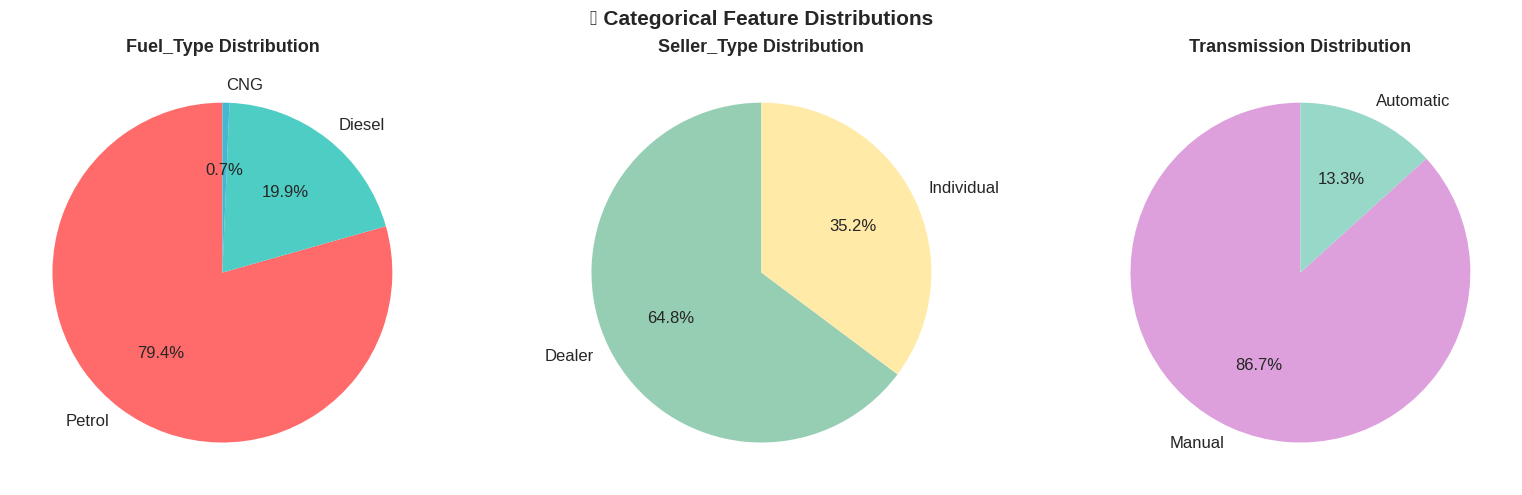

In [6]:
# ── Step 3: EDA ───────────────────────────────────────────────────────────────
# Add engineered feature: Car Age
df['Car_Age'] = 2025 - df['Year']

# Categorical value counts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
colors_list = [['#FF6B6B','#4ECDC4','#45B7D1'], ['#96CEB4','#FFEAA7'], ['#DDA0DD','#98D8C8']]

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=colors_list[i], startangle=90, textprops={'fontsize':12})
    axes[i].set_title(f'{col} Distribution', fontsize=13, fontweight='bold')

plt.suptitle('🚗 Categorical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_dist.png', dpi=150, bbox_inches='tight')
plt.show()

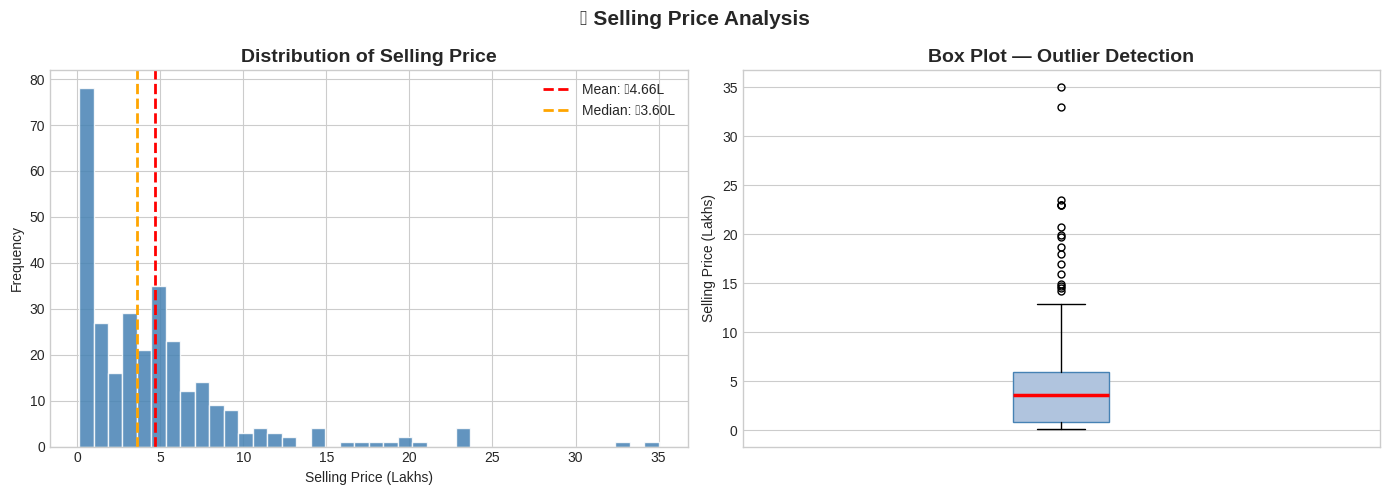

Skewness: 2.493  (right-skewed — most cars are affordable)


In [7]:
# Selling Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Selling_Price'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Selling_Price'].mean(), color='red', ls='--', lw=2, label=f'Mean: ₹{df["Selling_Price"].mean():.2f}L')
axes[0].axvline(df['Selling_Price'].median(), color='orange', ls='--', lw=2, label=f'Median: ₹{df["Selling_Price"].median():.2f}L')
axes[0].set_title('Distribution of Selling Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Selling Price (Lakhs)'); axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['Selling_Price'], patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
    medianprops=dict(color='red', linewidth=2.5),
    flierprops=dict(marker='o', color='red', markersize=5))
axes[1].set_title('Box Plot — Outlier Detection', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Selling Price (Lakhs)'); axes[1].set_xticks([])

plt.suptitle('💰 Selling Price Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Skewness: {df["Selling_Price"].skew():.3f}  (right-skewed — most cars are affordable)')

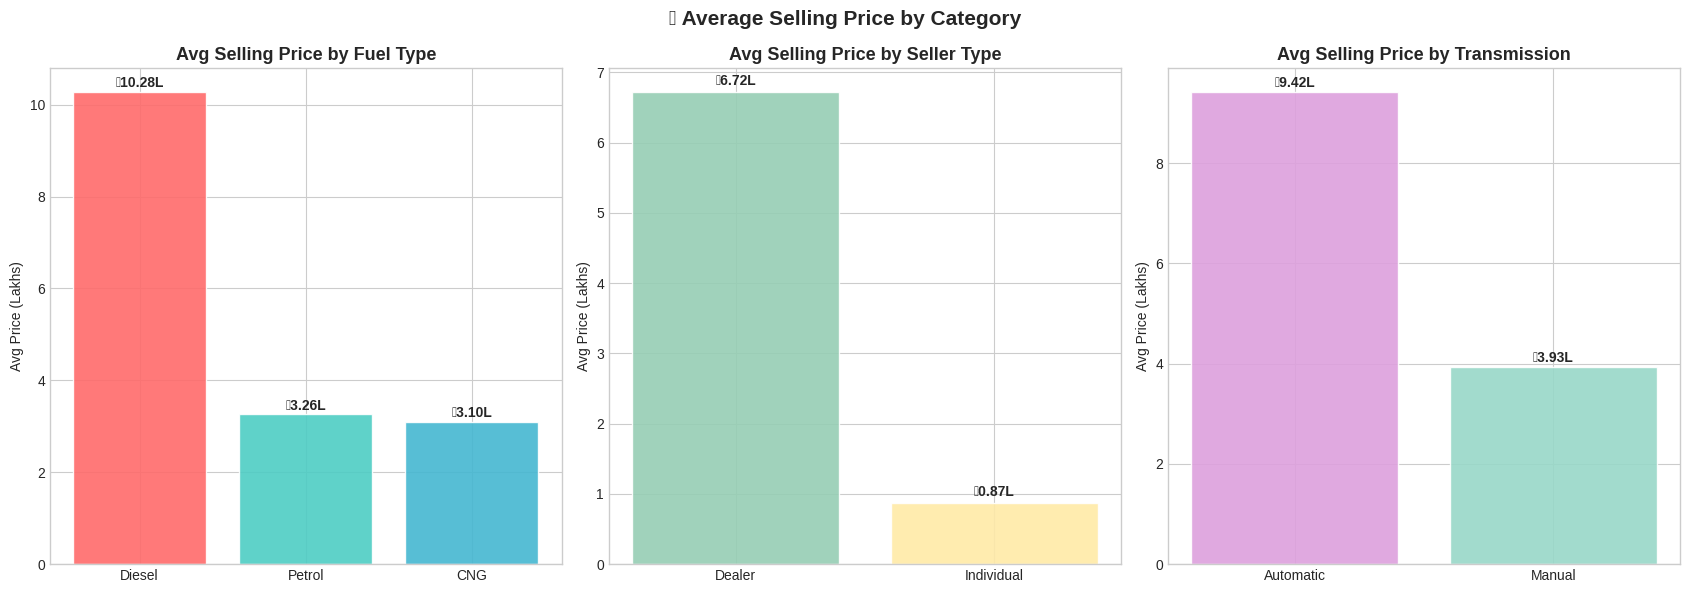

In [8]:
# Price by Category comparisons
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# Fuel Type vs Price
fuel_means = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
bars = axes[0].bar(fuel_means.index, fuel_means.values,
                   color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='white', alpha=0.9)
axes[0].set_title('Avg Selling Price by Fuel Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Price (Lakhs)')
for bar, val in zip(bars, fuel_means.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'₹{val:.2f}L', ha='center', fontweight='bold')

# Seller Type vs Price
seller_means = df.groupby('Seller_Type')['Selling_Price'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(seller_means.index, seller_means.values,
                    color=['#96CEB4','#FFEAA7'], edgecolor='white', alpha=0.9)
axes[1].set_title('Avg Selling Price by Seller Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Price (Lakhs)')
for bar, val in zip(bars2, seller_means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'₹{val:.2f}L', ha='center', fontweight='bold')

# Transmission vs Price
trans_means = df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
bars3 = axes[2].bar(trans_means.index, trans_means.values,
                    color=['#DDA0DD','#98D8C8'], edgecolor='white', alpha=0.9)
axes[2].set_title('Avg Selling Price by Transmission', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Price (Lakhs)')
for bar, val in zip(bars3, trans_means.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'₹{val:.2f}L', ha='center', fontweight='bold')

plt.suptitle('💹 Average Selling Price by Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('price_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

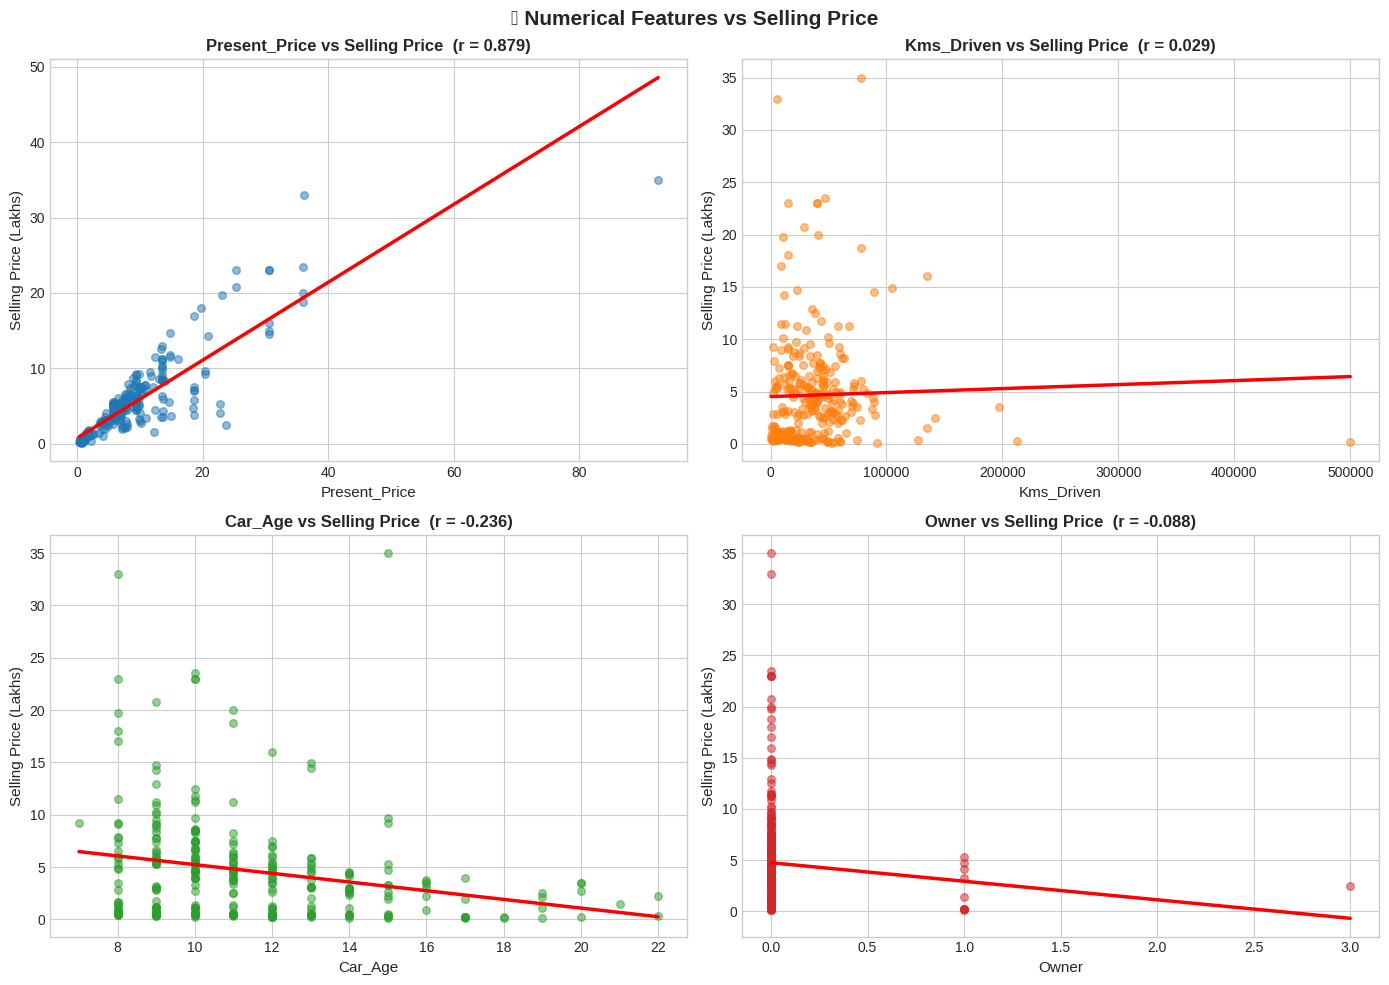

In [9]:
# Numerical Feature Scatter Plots vs Selling Price
num_features = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']
palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    axes[i].scatter(df[feature], df['Selling_Price'], alpha=0.5, color=palette[i], s=30)
    z = np.polyfit(df[feature], df['Selling_Price'], 1)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), 'r-', lw=2.5)
    r_val = df[feature].corr(df['Selling_Price'])
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Selling Price (Lakhs)', fontsize=11)
    axes[i].set_title(f'{feature} vs Selling Price  (r = {r_val:.3f})', fontsize=12, fontweight='bold')

plt.suptitle('📈 Numerical Features vs Selling Price', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Step 4: Preprocessing ─────────────────────────────────────────────────────
df_model = df.copy()

# Drop Car_Name (too many unique values, not useful for regression)
df_model.drop('Car_Name', axis=1, inplace=True)

# Label Encoding for categorical columns
le = LabelEncoder()
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
encoding_map = {}
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col}: {encoding_map[col]}')

print('\n✅ Categorical features encoded!')
print('\nSample encoded data:')
df_model.head(3)

  Fuel_Type: {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
  Seller_Type: {'Dealer': np.int64(0), 'Individual': np.int64(1)}
  Transmission: {'Automatic': np.int64(0), 'Manual': np.int64(1)}

✅ Categorical features encoded!

Sample encoded data:


,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,2014,3.35,5.59,27000,2,0,1,0,11
1,2013,4.75,9.54,43000,1,0,1,0,12
2,2017,7.25,9.85,6900,2,0,1,0,8


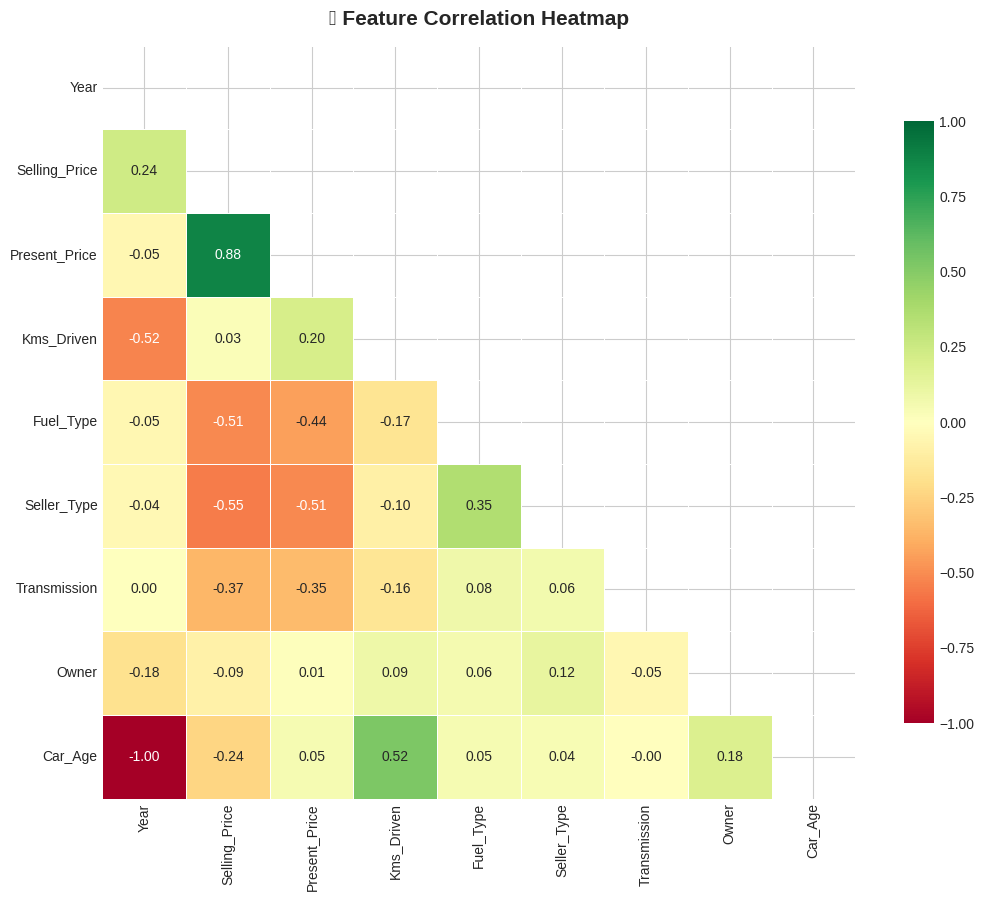


📊 Correlations with Selling_Price:
  Present_Price    █████████████████████        +0.8790
  Seller_Type      █████████████                -0.5507
  Fuel_Type        ████████████                 -0.5095
  Transmission     █████████                    -0.3671
  Year             █████                        +0.2361
  Car_Age          █████                        -0.2361
  Owner            ██                           -0.0883
  Kms_Driven                                    +0.0292


In [11]:
# Correlation Heatmap (after encoding)
plt.figure(figsize=(11, 9))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('🔗 Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Correlations with Selling_Price:')
price_corr = corr['Selling_Price'].drop('Selling_Price').sort_values(key=abs, ascending=False)
for feat, val in price_corr.items():
    bar = '█' * int(abs(val) * 25)
    print(f'  {feat:<16} {bar:<28} {val:+.4f}')

In [12]:
# Train-Test Split & Scaling
X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'✅ Features: {list(X.columns)}')
print(f'✅ Scaled with StandardScaler')

✅ Train: 240 samples  |  Test: 61 samples
✅ Features: ['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
✅ Scaled with StandardScaler


In [13]:
# ── Step 5: Train 5 Models ────────────────────────────────────────────────────
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Decision Tree':      DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []
trained_models = {}
print('🚀 Training Models...')
print('=' * 75)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv   = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    results.append({'Model': name, 'R² Score': round(r2,4), 'RMSE': round(rmse,4),
                    'MAE': round(mae,4), 'CV R² Mean': round(cv.mean(),4)})
    trained_models[name] = (model, y_pred)
    print(f'  ✅ {name:<25} | R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f} | CV={cv.mean():.4f}')

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False).reset_index(drop=True)
print('\n🏆 Final Leaderboard:')
results_df

🚀 Training Models...
  ✅ Linear Regression         | R²=0.8468 | RMSE=1.8785 | MAE=1.2218 | CV=0.8446
  ✅ Ridge Regression          | R²=0.8464 | RMSE=1.8809 | MAE=1.2227 | CV=0.8467
  ✅ Decision Tree             | R²=0.9183 | RMSE=1.3716 | MAE=0.7794 | CV=0.8157
  ✅ Random Forest             | R²=0.9649 | RMSE=0.8991 | MAE=0.6009 | CV=0.8805
  ✅ Gradient Boosting         | R²=0.9720 | RMSE=0.8025 | MAE=0.5154 | CV=0.8877

🏆 Final Leaderboard:


,Model,R² Score,RMSE,MAE,CV R² Mean
0,Gradient Boosting,0.9720,0.8025,0.5154,0.8877
1,Random Forest,0.9649,0.8991,0.6009,0.8805
2,Decision Tree,0.9183,1.3716,0.7794,0.8157
3,Linear Regression,0.8468,1.8785,1.2218,0.8446
4,Ridge Regression,0.8464,1.8809,1.2227,0.8467


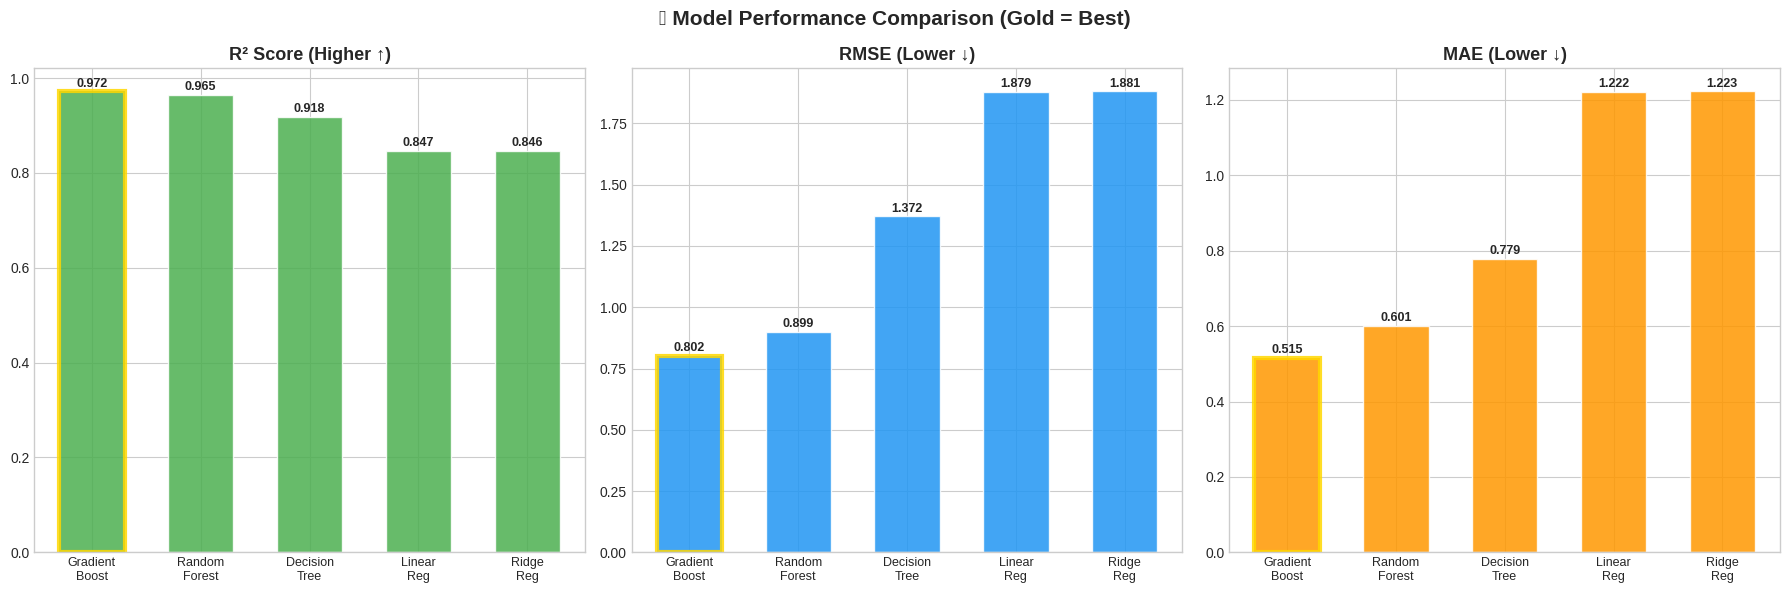

In [14]:
# ── Step 6: Model Comparison Charts ──────────────────────────────────────────
short_names = [n.replace(' Regression','\nReg').replace(' Boosting','\nBoost')
                .replace(' Forest','\nForest').replace(' Tree','\nTree')
               for n in results_df['Model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_info = [('R² Score','#4CAF50','Higher ↑'), ('RMSE','#2196F3','Lower ↓'), ('MAE','#FF9800','Lower ↓')]

for i, (metric, color, note) in enumerate(metrics_info):
    vals = results_df[metric].values
    bars = axes[i].bar(range(len(vals)), vals, color=color, alpha=0.85, edgecolor='white', width=0.6)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(short_names, fontsize=9)
    axes[i].set_title(f'{metric} ({note})', fontsize=13, fontweight='bold')
    best_idx = vals.argmax() if metric == 'R² Score' else vals.argmin()
    bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(3)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('🏆 Model Performance Comparison (Gold = Best)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 Best Model: Gradient Boosting  |  R² = 0.972


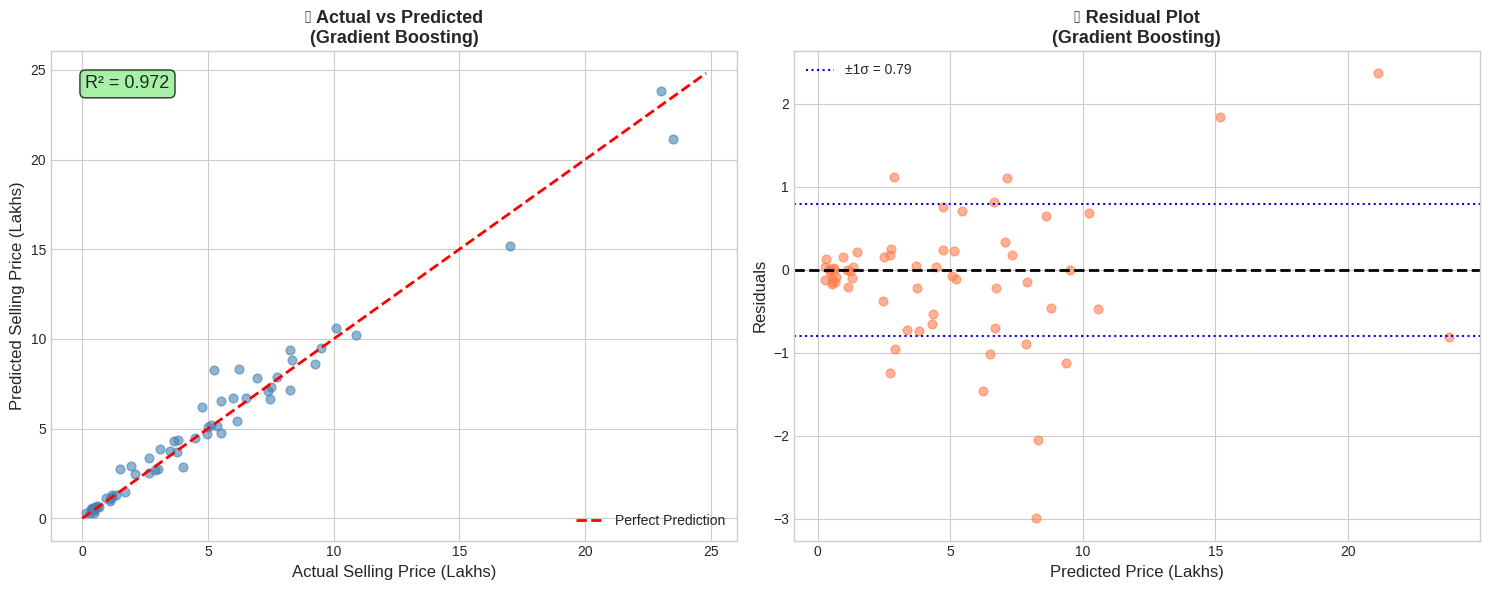

In [15]:
# Actual vs Predicted + Residuals
best_name = results_df.iloc[0]['Model']
best_model, y_pred_best = trained_models[best_name]
print(f'🏆 Best Model: {best_name}  |  R² = {results_df.iloc[0]["R² Score"]}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', s=40)
lims = [0, max(y_test.max(), y_pred_best.max())+1]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Selling Price (Lakhs)', fontsize=12)
axes[0].set_ylabel('Predicted Selling Price (Lakhs)', fontsize=12)
axes[0].set_title(f'🎯 Actual vs Predicted\n({best_name})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {results_df.iloc[0]["R² Score"]}',
             transform=axes[0].transAxes, fontsize=13, va='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='coral', s=40)
axes[1].axhline(y=0, color='black', ls='--', lw=2)
axes[1].axhline(y=residuals.std(), color='blue', ls=':', lw=1.5, label=f'±1σ = {residuals.std():.2f}')
axes[1].axhline(y=-residuals.std(), color='blue', ls=':', lw=1.5)
axes[1].set_xlabel('Predicted Price (Lakhs)', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'📉 Residual Plot\n({best_name})', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

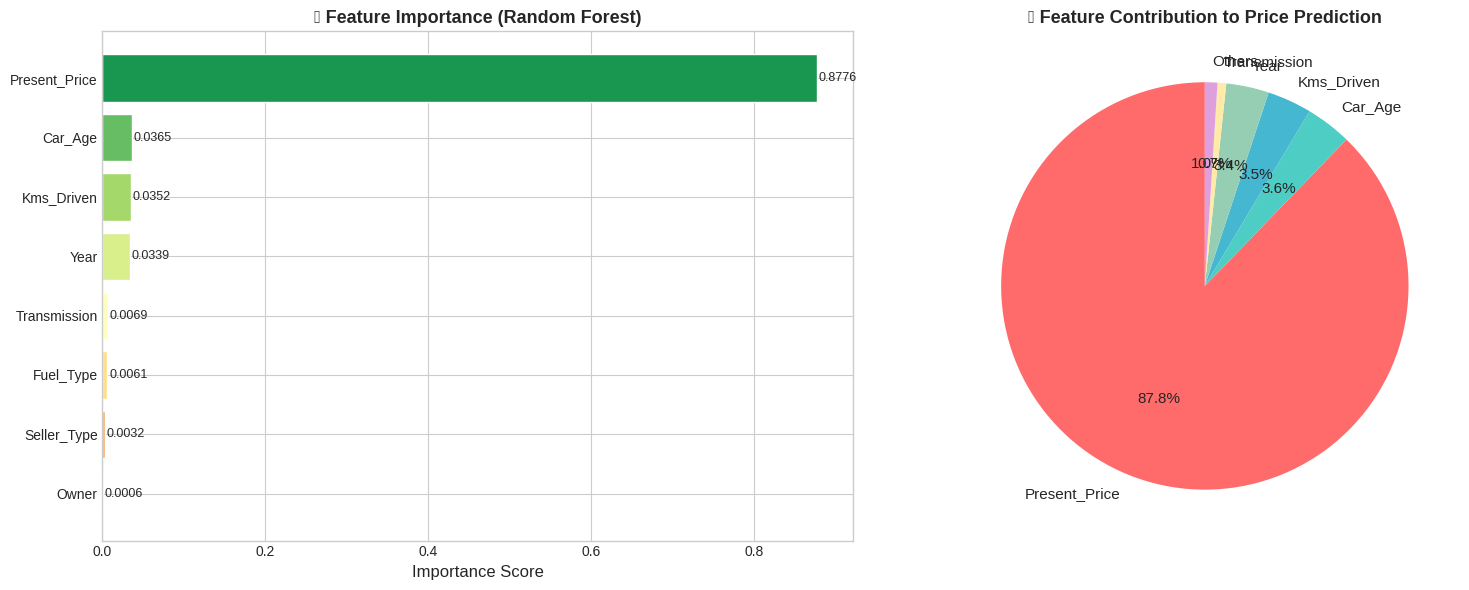

🔑 Feature Rankings:
   Present_Price   : ██████████████████████████████████████████████████████████████████████ 0.8776 (87.8%)
   Car_Age         : ██                   0.0365 (3.6%)
   Kms_Driven      : ██                   0.0352 (3.5%)
   Year            : ██                   0.0339 (3.4%)
   Transmission    :                      0.0069 (0.7%)
   Fuel_Type       :                      0.0061 (0.6%)
   Seller_Type     :                      0.0032 (0.3%)
   Owner           :                      0.0006 (0.1%)


In [16]:
# ── Step 7: Feature Importance ────────────────────────────────────────────────
rf_model = trained_models['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
bars = axes[0].barh(importances.index, importances.values, color=colors_fi, edgecolor='white')
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('🌲 Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, importances.values):
    axes[0].text(val+0.002, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

top5 = importances.sort_values(ascending=False).head(5)
rest = 1 - top5.sum()
pie_data   = list(top5.values) + ([rest] if rest > 0 else [])
pie_labels = list(top5.index) + (['Others'] if rest > 0 else [])
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90,
            colors=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD'],
            textprops={'fontsize': 11})
axes[1].set_title('🥧 Feature Contribution to Price Prediction', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('🔑 Feature Rankings:')
for feat, val in importances.sort_values(ascending=False).items():
    bar_str = '█' * int(val * 80)
    print(f'   {feat:<16}: {bar_str:<20} {val:.4f} ({val*100:.1f}%)')

In [17]:
# ── Step 8: Sample Predictions ────────────────────────────────────────────────
print(f'🔮 Sample Predictions — Best Model: {best_name}')
print('=' * 62)
for i in range(6):
    pred   = best_model.predict(scaler.transform(X_test.iloc[[i]]))[0]
    actual = y_test.iloc[i]
    err    = abs(pred - actual) / actual * 100
    print(f'  #{i+1}  Actual=₹{actual:.2f}L  |  Predicted=₹{pred:.2f}L  |  Error={err:.1f}% {"✅" if err<15 else "⚠️"}')

# Custom car prediction
print('\n🚗 Custom Car Prediction:')
# Encoding: Fuel_Type: CNG=0,Diesel=1,Petrol=2 | Seller_Type: Dealer=0,Individual=1 | Transmission: Automatic=0,Manual=1
custom_car = pd.DataFrame([{
    'Year': 2019, 'Present_Price': 8.0, 'Kms_Driven': 35000,
    'Fuel_Type': encoding_map['Fuel_Type']['Petrol'],
    'Seller_Type': encoding_map['Seller_Type']['Individual'],
    'Transmission': encoding_map['Transmission']['Manual'],
    'Owner': 1, 'Car_Age': 2025-2019
}], columns=X.columns)
pred_custom = best_model.predict(scaler.transform(custom_car))[0]
print(f'   Input: 2019 Petrol car | Showroom ₹8L | 35,000 kms | Individual seller | Manual')
print(f'   🎯 Predicted Selling Price: ₹{pred_custom:.2f} Lakhs')

🔮 Sample Predictions — Best Model: Gradient Boosting
  #1  Actual=₹0.35L  |  Predicted=₹0.52L  |  Error=49.5% ⚠️
  #2  Actual=₹10.11L  |  Predicted=₹10.59L  |  Error=4.7% ✅
  #3  Actual=₹4.95L  |  Predicted=₹4.71L  |  Error=4.8% ✅
  #4  Actual=₹0.15L  |  Predicted=₹0.27L  |  Error=81.0% ⚠️
  #5  Actual=₹6.95L  |  Predicted=₹7.85L  |  Error=12.9% ✅
  #6  Actual=₹7.45L  |  Predicted=₹6.64L  |  Error=10.9% ✅

🚗 Custom Car Prediction:
   Input: 2019 Petrol car | Showroom ₹8L | 35,000 kms | Individual seller | Manual
   🎯 Predicted Selling Price: ₹6.50 Lakhs
